# Monte Carlo Simulation and the Mathematics of Gambling
## Can a player beat the casino in the long run?

Author: Yoan Angelov

## 1. Introduction

Gambling has existed for centuries and remains popular worldwide. Many players believe that with the right strategy, they can beat the casino. However, gambling games are designed using probability theory, which often guarantees a long-term advantage for the house.

This project investigates whether a player can mathematically beat the casino in the long run using Monte Carlo simulations.

I will simulate simple gambling games and analyze them using probability theory, expected value, and experimental results.

## 2. Problem Formulation


### Research Question

Is it mathematically possible for a player to beat the casino in the long run?

### Objectives

- Simulate simple gambling games using Python
- Compare theoretical probabilities with experimental results
- Analyze expected value
- Test a betting strategy ((Martingale system)  - After a loss, you double your next bet;Continue doing this until you succeed; When you win, you return to your initial bet.)
- Interpret results using mathematical reasoning

### Hypothesis

Although players may win in the short term, probability theory suggests that long-term profit is unlikely due to the house edge.

## 3. Theoretical Background


### 3.1 Basic Probability
Probability measures how likely an event is to occur. It ranges between 0 and 1.
For example, in a fair coin toss:
$$
P(H) = 0.5
$$

$$
P(T) = 0.5
$$

Where
- \(H\) represents Heads
- \(T\) represents Tails



### 3.2 Expected Value
Expected value - (EV) represents the average outcome of a game over many repetitions.

EV of the game can be calculated using the formula:

$$
EV = \sum P(x_i) \cdot x_i
$$

For the coin flip game:

$$
EV = \left(\frac{1}{2} \times 1\right) + \left(\frac{1}{2} \times (-1)\right)
$$

$$
EV = 0
$$

This means that the game is fair and the player neither gains nor loses money on average.

If EV = 0 → fair game  
If EV < 0 → player loses long-term  
If EV > 0 → player wins long-term 



### 3.3 Law of Large Numbers
The Law of Large Numbers states that as the number of trials increases, experimental results approach theoretical probabilities.

This concept is fundamental in Monte Carlo simulations.

## 4. Game 1: Coin Flip Simulation

### 4.1  Coin Flip Simulation Code Explanation

The following Python code simulates a simple coin flip game using a Monte Carlo approach.

We assume a fair coin with two possible outcomes: Heads or Tails.

- If the result is Heads, the player wins 1 unit.
- If the result is Tails, the player loses 1 unit.

The simulation tracks the player's balance over many repeated games. This allows us to visualize how the balance fluctuates due to randomness.

### 4.2 The simulation uses two Python libraries:

- `random` is used to generate random outcomes for the coin flips.
- `matplotlib` is used to create a graph that visualizes the player's balance over time.

### 4.3 The function `simulate_coin_flips()` performs the simulation.

It takes one parameter:

- `num_flips` – the number of simulated coin flips.

The function keeps track of the player's balance and stores the balance after each game. These values are saved in a list so they can later be plotted on a graph.

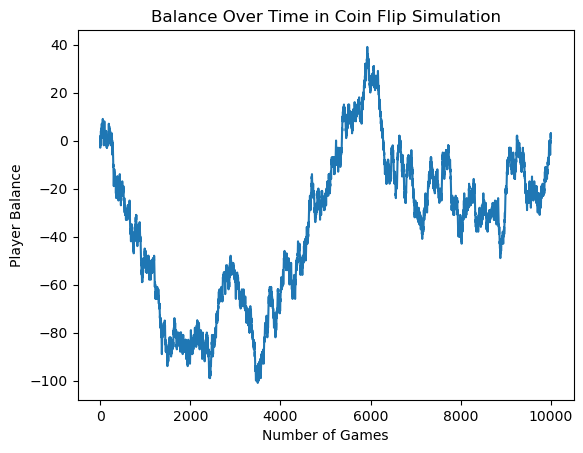

In [18]:
import random
import matplotlib.pyplot as plt

def simulate_coin_flips(num_flips):

    balance = 0
    balances = []

    for i in range(num_flips):

        flip = random.choice(["H", "T"])

        if flip == "H":
            balance += 1
        else:
            balance -= 1

        balances.append(balance)

    return balances


results = simulate_coin_flips(10000)

plt.plot(results)
plt.title("Balance Over Time in Coin Flip Simulation")
plt.xlabel("Number of Games")
plt.ylabel("Player Balance")

plt.show()


The graph shows how the player's balance changes over time.
Even though the expected value of the game is zero, short-term
results fluctuate randomly due to variance.

Note: The simulation starts with a balance of 0. 
This represents the player's net profit or loss relative to the starting point.

## 5. Game 2: Roulette Simulation
In the second experiment we simulate a simplified version of European roulette.

Roulette is a casino game where a ball lands on one of 37 numbered slots
(0–36). Players place bets on different outcomes and receive payouts depending
on the type of bet.

In this simulation we consider the simplest possible strategy: betting on a
single number every time.


### 5.1 Theoretical Analysis

In European roulette there are 37 possible outcomes:

0, 1, 2, ..., 36

If a player bets on a single number, the probability of winning is:

$$
P(\text{win}) = \frac{1}{37}
$$

The probability of losing is:

$$
P(\text{loss}) = \frac{36}{37}
$$

The payout for a correct number is 35:1.

The expected value of the game can therefore be calculated as:

$$
EV = \left(\frac{1}{37} \times 35\right) + \left(\frac{36}{37} \times (-1)\right)
$$

$$
EV \approx -0.027
$$

This means that the player loses approximately **2.7% per bet on average**.
This advantage is known as the **house edge**, which ensures that casinos make
a profit in the long run.

### 5.2 Implementation
The following Python function simulates a player repeatedly betting on a
single number in roulette.

Each spin of the wheel produces a random number between 0 and 36.

If the selected number appears, the player wins 35 units. Otherwise the player
loses 1 unit.

The simulation tracks the player's balance over time in order to visualize
how the casino advantage affects long-term results.

In [8]:
import random

def roulette_simulation(num_spins):

    balance = 0
    results = []

    for _ in range(num_spins):

        spin = random.randint(0, 36)

        if spin == 7:  # player bets on number 7
            balance += 35
        else:
            balance -= 1

        results.append(balance)

    return results

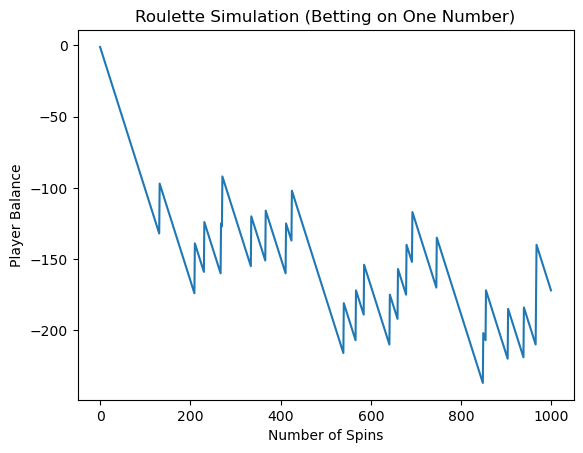

In [9]:
import matplotlib.pyplot as plt

results = roulette_simulation(1000)

plt.plot(results)

plt.title("Roulette Simulation (Betting on One Number)")
plt.xlabel("Number of Spins")
plt.ylabel("Player Balance")

plt.show()

The graph shows the player's balance as the number of roulette spins increases.

The horizontal axis represents the number of spins played, while the vertical
axis represents the player's cumulative balance.

Because the expected value of the game is negative, the player's balance tends
to decrease over time. Short-term fluctuations are possible, but the long-term
trend typically moves downward due to the house edge.

## 6. Betting Strategy: Martingale System
The Martingale strategy is one of the most well-known betting systems used in
gambling.

The idea of the strategy is simple:

- The player starts with a small bet.
- After every loss, the player doubles the bet.
- When a win occurs, the player recovers all previous losses and gains a
small profit equal to the initial bet.

At first glance this strategy appears attractive because a single win can
recover a sequence of losses.

However, the required bet size grows exponentially during losing streaks,
which can quickly lead to very large losses.


### Martingale Simulation Implementation

The following simulation applies the Martingale strategy to the roulette game.

After each losing spin, the bet size is doubled. If the player wins, the bet
is reset to the original base bet.

The simulation tracks the player's balance in order to observe how the
strategy behaves over multiple spins.

In [3]:
import random
import matplotlib.pyplot as plt

def martingale_simulation(spins, base_bet=1):

    balance = 0
    bet = base_bet
    balances = []

    for i in range(spins):

        spin = random.randint(0, 36)

        if spin == 7:   # chosen number
            balance += 35 * bet
            bet = base_bet
        else:
            balance -= bet
            bet *= 2

        balances.append(balance)

    return balances

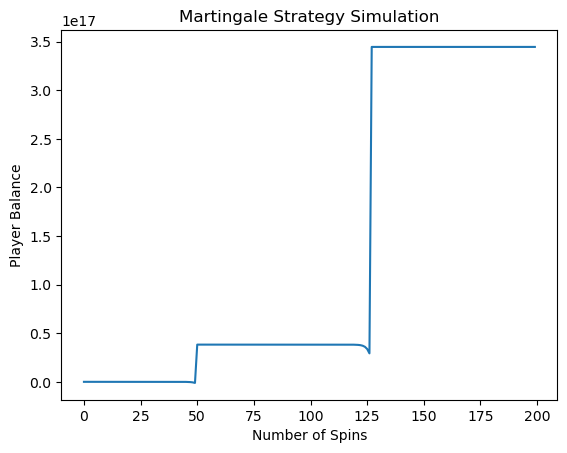

In [4]:
result = martingale_simulation(200)

plt.plot(result)

plt.title("Martingale Strategy Simulation")
plt.xlabel("Number of Spins")
plt.ylabel("Player Balance")

plt.show()

The graph illustrates how the player's balance evolves when using the
Martingale betting strategy.

In many cases the player experiences small and frequent gains. However,
when a long losing streak occurs, the required bet grows very quickly,
leading to large losses.

This demonstrates an important concept in probability theory: betting
strategies cannot eliminate the negative expected value of the game.

## 7. Experimental Results

### 7.1 Coin Flip Results
The coin flip simulation shows fluctuations around zero. This is expected
because the game is fair and has an expected value of zero.

$$
EV = 0
$$

Although the balance may move up or down in the short term, the average
result tends to remain close to zero as the number of games increases.
This behavior illustrates the role of randomness and variance in fair games.

### 7.2 Roulette Results

The roulette simulation demonstrates a downward trend over time. This occurs
because the house edge gives the casino a statistical advantage.

$$
EV \approx -0.027
$$

This negative expected value means that the player loses on average about
2.7% of each bet. While short-term wins are possible, the long-term trend
typically favors the casino.

### 7.3 Martingale Results
The Martingale strategy appears successful in the short term because small
losses are recovered quickly. However, when a long losing streak occurs, the
required bet grows exponentially, leading to very large losses.

This exponential growth can quickly exceed the player's available funds,
leading to very large losses. As a result, the strategy does not eliminate
the negative expected value of the game.

## 8. Discussion

- Why short-term wins are misleading - Short sequences of wins can create the illusion that a strategy works.
However, probability ensures that losing streaks will eventually occur.
- The role of variance - Variance causes large fluctuations in short-term results. Monte Carlo
simulations help visualize how randomness behaves over time.
- The importance of expected value - Expected value determines the long-term outcome of a game. If the expected
value is negative, no betting strategy can overcome the house edge in the
long run 


## 9. Conclusion

This project demonstrated that although gambling may produce short-term gains,
probability theory and simulations confirm that long-term profit is unlikely in games with negative expected value.

## References
Wikipedia – Expected Value

Wikipedia – Martingale Betting System

Wikipedia – Monte Carlo Method  

Wikipedia – Roulette

Wikipedia - Coin flipping

https://www.cmor-faculty.rice.edu/~heinken/latex/symbols.pdf

Let X be a random variable representing the outcome of a single coin flip:

$$
X =
\begin{cases}
+1, & \text{if the player wins} \\
-1, & \text{if the player loses}
\end{cases}
$$

The expected value is:

$$
EV = E[X] = (0.5)(1) + (0.5)(-1) = 0
$$

This confirms that the coin flip game is fair (Grinstead & Snell, 1997, Chapter 6).